# IT3385 Assignment Exploratory Data Analysis


Modelling task: binary classification of `maintenance_required`, which rows
require maintenance (`1`) vs not (`0`).

Features we keep (predictors): `temperature`, `vibration`, `humidity`,
`pressure`, `energy_consumption`, `machine_status`, `anomaly_flag`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import mutual_info_classif

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
TARGET = "maintenance_required"
SENSORS = ["temperature", "vibration", "humidity", "pressure", "energy_consumption"]
KEPT_FEATURES = SENSORS
DROP_FEATURES = ["timestamp", "machine_id", "failure_type",
                 "downtime_risk", "predicted_remaining_life",
                 "machine_status", "anomaly_flag"]


## 1. Setup & Data Overview


In [2]:
df = pd.read_csv("../data/raw/smart_manufacturing_data.csv", parse_dates=["timestamp"])
print("Shape:", df.shape)
df.head()


Shape: (100000, 13)


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   timestamp                 100000 non-null  datetime64[ns]
 1   machine_id                100000 non-null  int64         
 2   temperature               100000 non-null  float64       
 3   vibration                 100000 non-null  float64       
 4   humidity                  100000 non-null  float64       
 5   pressure                  100000 non-null  float64       
 6   energy_consumption        100000 non-null  float64       
 7   machine_status            100000 non-null  int64         
 8   anomaly_flag              100000 non-null  int64         
 9   predicted_remaining_life  100000 non-null  int64         
 10  failure_type              100000 non-null  object        
 11  downtime_risk             100000 non-null  float64       
 12  mai

In [4]:
print("Total missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate (machine_id, timestamp) pairs:", df.duplicated(subset=["machine_id", "timestamp"]).sum())
print("Unique machines:", df["machine_id"].nunique())


Total missing values: 0
Duplicate rows: 0
Duplicate (machine_id, timestamp) pairs: 0
Unique machines: 50


In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
timestamp,100000,NaN,NaN,NaN,2025-02-04 17:19:29.999999744,2025-01-01 00:00:00,2025-01-18 08:39:45,2025-02-04 17:19:30,2025-02-22 01:59:15,2025-03-11 10:39:00,NaN
machine_id,100000.0,NaN,NaN,NaN,25.49933,1.0,13.0,25.0,38.0,50.0,14.389439
temperature,100000.0,NaN,NaN,NaN,75.015625,35.55,68.2675,75.06,81.75,121.94,10.031884
vibration,100000.0,NaN,NaN,NaN,50.01227,-17.09,39.97,49.96,60.1,113.8,14.985444
humidity,100000.0,NaN,NaN,NaN,54.995401,30.0,42.52,54.98,67.5,80.0,14.43796
pressure,100000.0,NaN,NaN,NaN,3.000405,1.0,2.0,3.01,4.0,5.0,1.152399
energy_consumption,100000.0,NaN,NaN,NaN,2.747064,0.5,1.63,2.74,3.87,5.0,1.297865
machine_status,100000.0,NaN,NaN,NaN,1.00205,0.0,1.0,1.0,1.0,2.0,0.446193
anomaly_flag,100000.0,NaN,NaN,NaN,0.08916,0.0,0.0,0.0,0.0,1.0,0.284976
predicted_remaining_life,100000.0,NaN,NaN,NaN,234.26916,1.0,97.0,230.0,365.0,499.0,150.063062


**Observations:**
- 100,000 rows, 13 columns, 50 distinct machines.
- No missing values and no duplicate rows → no imputation / deduplication needed.
- Columns split into two groups for this task:
  - **Kept:** the 5 sensors + `machine_status` + `anomaly_flag`.
  - **Dropped:** `timestamp`, `machine_id` (identifiers), `failure_type`,
    `downtime_risk`, `predicted_remaining_life`.
- Sampling is **irregular**: readings are not "one per minute" and the median gap
  between consecutive readings for a machine is ~35 minutes. 

## 2. Target Analysis of column `maintenance_required`


In [6]:
ax = sns.countplot(x=TARGET, data=df, palette="viridis")
total = len(df)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.annotate(f"{p.get_height():,.0f}\n({pct:.1f}%)",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
ax.set_title("maintenance_required distribution")
plt.tight_layout()
plt.show()

print(df[TARGET].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")


C:\Users\glenv\AppData\Local\Temp\ipykernel_39808\359821146.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=TARGET, data=df, palette="viridis")


<Figure size 1000x500 with 1 Axes>

maintenance_required
0    80.3%
1    19.7%
Name: proportion, dtype: object


**Observation:**
- `maintenance_required` is imbalanced: ~80.3% `0` vs ~19.7% `1`.
- Accuracy would be misleading, so the PyCaret pipeline should use **SMOTE**
  (`fix_imbalance`) and optimise **F1 / PR-AUC** instead of accuracy since class imbalance means accuracy is no longer a trustworthy metric to evaluate the model on.


## 3. Leakage Diagnosis justifying `drop_features`

Before modelling we check which columns encode the target (or future information)
in a way that would leak.


### 3.1 `downtime_risk` is a near-duplicate of `anomaly_flag`


Correlation downtime_risk vs anomaly_flag: 0.999998


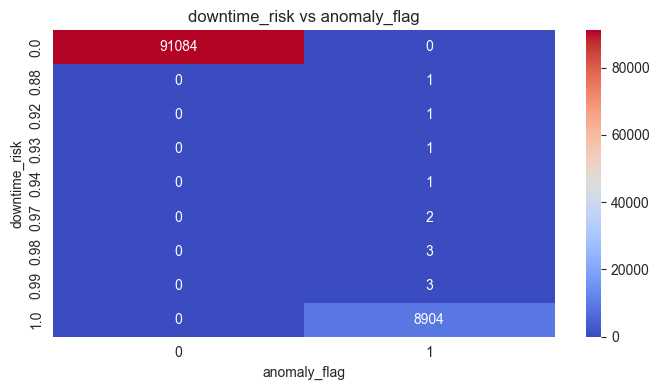

In [7]:
print("Correlation downtime_risk vs anomaly_flag:",
      round(df["downtime_risk"].corr(df["anomaly_flag"]), 6))

ct = pd.crosstab(df["downtime_risk"], df["anomaly_flag"])
plt.figure(figsize=(7, 4))
sns.heatmap(ct, annot=True, fmt="d", cmap="coolwarm")
plt.title("downtime_risk vs anomaly_flag")
plt.tight_layout()
plt.show()


**Verdict:** `downtime_risk` and `anomaly_flag` carry the same information
(correlation ≈ 1.0). Drop `downtime_risk`, keep `anomaly_flag`.


### 3.2 `failure_type` reveals the maintenance label


maintenance_required      0      1
failure_type                      
Electrical Fault      0.000  1.000
Normal                0.874  0.126
Overheating           0.000  1.000
Pressure Drop         0.000  1.000
Vibration Issue       0.000  1.000


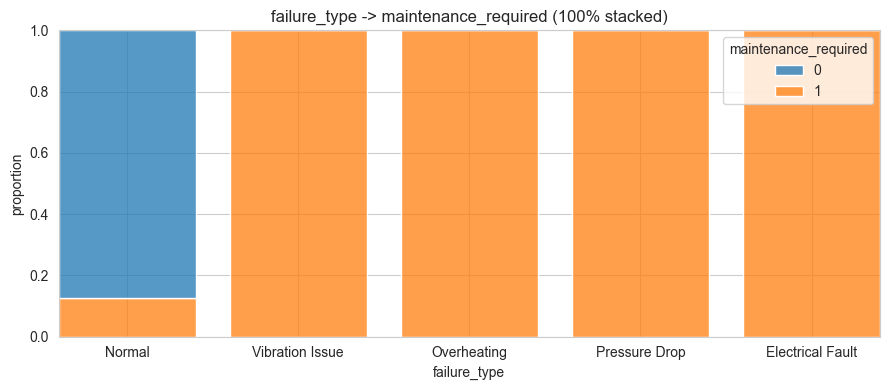

In [8]:
ct = pd.crosstab(df["failure_type"], df[TARGET], normalize="index")
print(ct.round(3))

plt.figure(figsize=(9, 4))
sns.histplot(df, x="failure_type", hue=TARGET, multiple="fill", shrink=0.8)
plt.ylabel("proportion")
plt.title("failure_type -> maintenance_required (100% stacked)")
plt.tight_layout()
plt.show()


**Verdict:** every non-`Normal` fault class is 100% `maintenance_required=1`,
so `failure_type` reveals the failure in advance hence I dropped the column.


### 3.3 `predicted_remaining_life` is a model output

Correlation predicted_remaining_life vs maintenance_required: -0.343


C:\Users\glenv\AppData\Local\Temp\ipykernel_39808\80154790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=TARGET, y="predicted_remaining_life", data=df, ax=axes[0], palette="Set2")


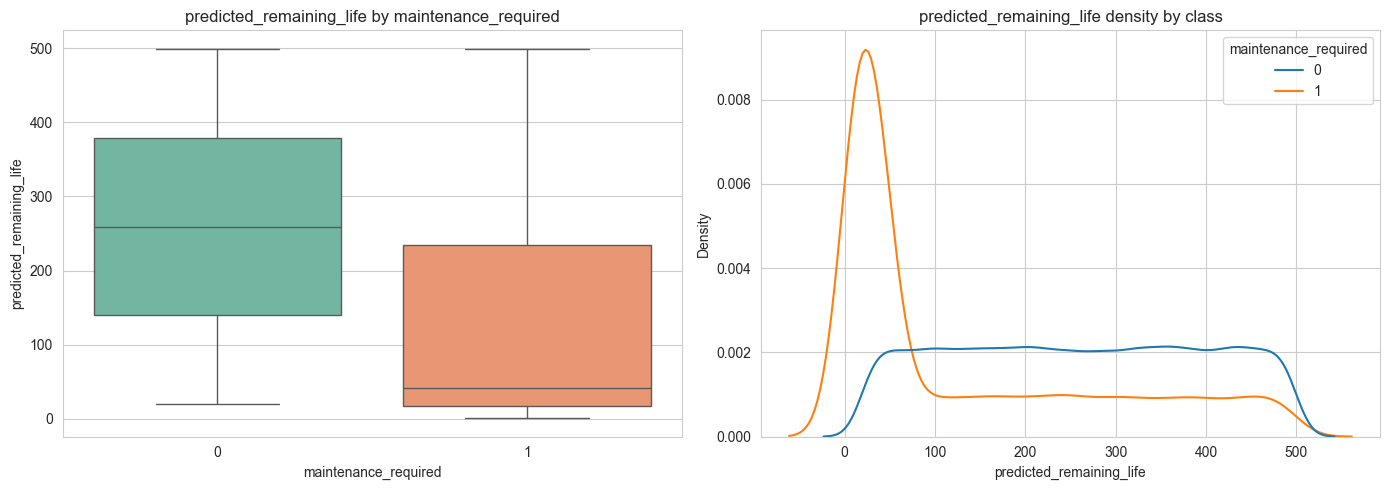

In [9]:
print("Correlation predicted_remaining_life vs maintenance_required:",
      round(df["predicted_remaining_life"].corr(df[TARGET]), 3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=TARGET, y="predicted_remaining_life", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("predicted_remaining_life by maintenance_required")
sns.kdeplot(data=df, x="predicted_remaining_life", hue=TARGET, common_norm=False, ax=axes[1])
axes[1].set_title("predicted_remaining_life density by class")
plt.tight_layout()
plt.show()


**Verdict** `predicted_remaining_life` is a model output and is target derived therefore we drop it.


### 3.4 `timestamp` and `machine_id` are identifiers

These are not causal predictors: `timestamp` is the sampling time and `machine_id`
is the machine label. We drop both and train a machine-agnostic model.


In [10]:
print("drop_features (leakage / identifiers):", DROP_FEATURES)
print("kept features:", KEPT_FEATURES)


drop_features (leakage / identifiers): ['timestamp', 'machine_id', 'failure_type', 'downtime_risk', 'predicted_remaining_life', 'machine_status', 'anomaly_flag']
kept features: ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption']


### 3.5 `machine_status` and `anomaly_flag` are target leakages. 

Section 4.1 below shows `machine_status` = 2 and `anomaly_flag` = 1 both correspond to `maintenance_required` = 1 with no exceptions detailing a deterministic relationship. This mirrors the pattern found for `failure_type` in section 3.2 these 2 features are likely derived, or recorded concurrently with the maintenance decision rather than being independent upstream records. Including them would let the model learn from features that simply would not exist during a real life scenario, meaning that the model would be useless in a real world scenario should the assumptions that these features being derived alongside or after the maintenance decision is made. 

## 4. Bivariate analysis of feature vs target


### 4.1 The two flags: `machine_status` and `anomaly_flag`


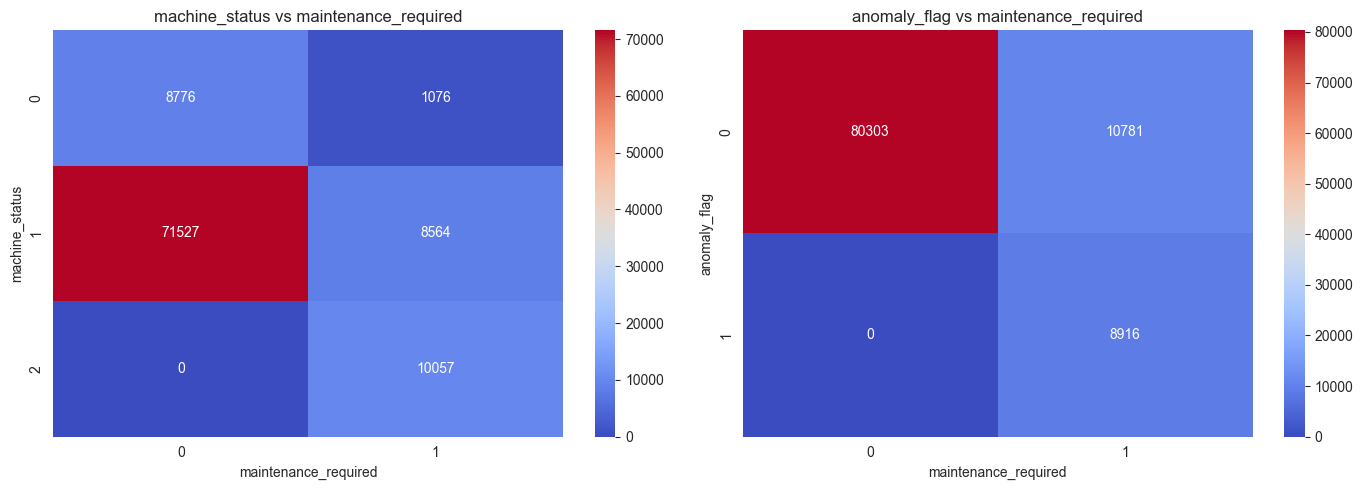

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ["machine_status", "anomaly_flag"]):
    ct = pd.crosstab(df[col], df[TARGET])
    sns.heatmap(ct, annot=True, fmt="d", cmap="coolwarm", ax=ax)
    ax.set_title(f"{col} vs maintenance_required")
plt.tight_layout()
plt.show()



**Observations:**
`machine_status` vs `maintenance_required`, both status 0 and 1 show `maintenance_required` split roughly 90/10 (not required / required) showing that there's no strong signal here. Status 2 however is a perfect predictor where all 10,057 rows with `machine_status` = 2 have `maintenance_required`, and 0 have `maintenance_required` as 0. `anomaly_flag` = 0 splits roughly 88 / 12 across the 2 classes. `anomaly_flag` = 1 is also a perfect predictor, where all 8916 rows hbave `maintenance_required` with no exceptions. This shows that these variables are deterministic, where every row with `machine_status` = 2 or `anomaly_flag` = 1, has `maintenance_required` = 1, which could be a sign of target leakage, suggesting that `machine_status` and `anomaly_flag` are not independent sensor readings and could be derived from the maintenance decision. 

### 4.2 Sensor readings by `maintenance_required`


C:\Users\glenv\AppData\Local\Temp\ipykernel_39808\3925649197.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=TARGET, y=col, data=df, ax=axes[i], palette="Set1")
C:\Users\glenv\AppData\Local\Temp\ipykernel_39808\3925649197.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=TARGET, y=col, data=df, ax=axes[i], palette="Set1")
C:\Users\glenv\AppData\Local\Temp\ipykernel_39808\3925649197.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=TARGET, y=col, data=df, ax=axes[i], palette="Set1")
C:\Users\glenv\AppData\Local\Temp\ipykernel_39

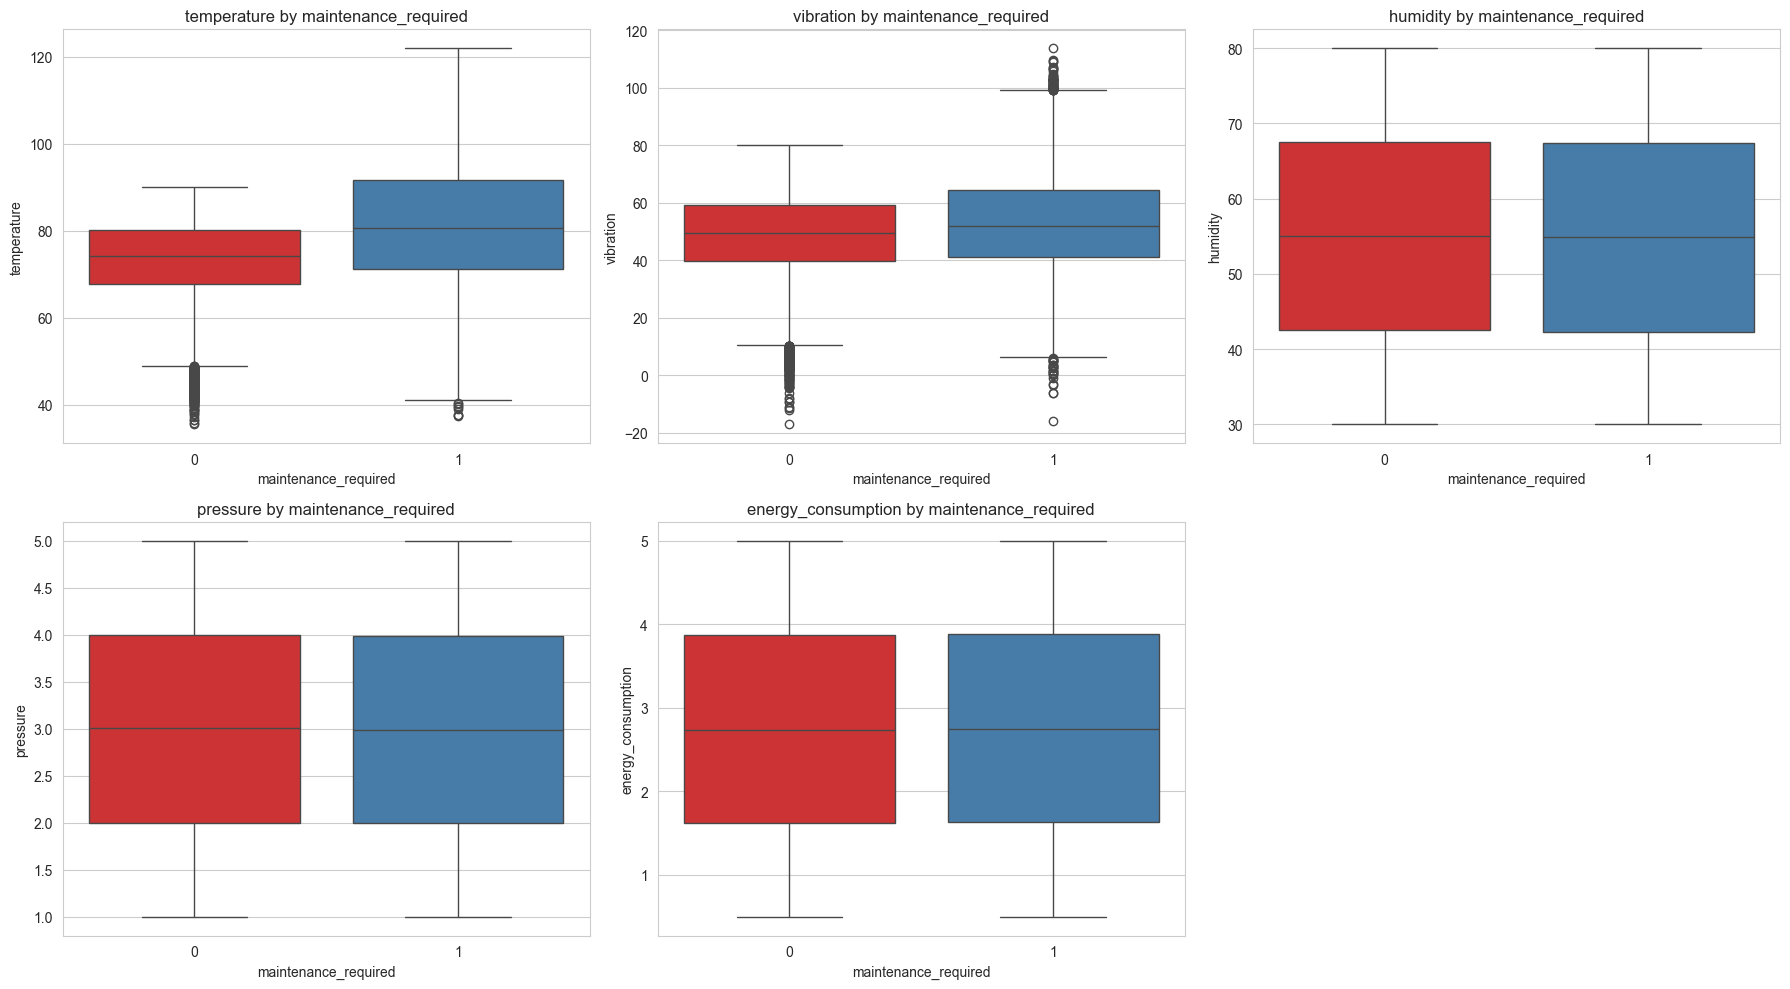

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(SENSORS):
    sns.boxplot(x=TARGET, y=col, data=df, ax=axes[i], palette="Set1")
    axes[i].set_title(f"{col} by maintenance_required")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


**Observation:** `temperature` shows the clearest separation between the two classes, machines flagged for maintenance typically exhibit higher median temperatures (80°C) as opposed to those not flagged (74°C) with a wider spread and a much higher upper whisker (up to 122°C). This suggests that temperatue is likely to be one of the strongest predictors of `maintenance_required`.  `Vibration` also shows a upward shift in median for `maintenance_required` = 1 (~52) vs `maintenance_required` = 0 (~49), though the interquartile range overlaps considerably. `Humidity`, `pressure` and `energy_consumption` show near identical distributions across both groups, with the medians, IQR and whiskers overlapping significantly, on their own these features seem to carry little to no discriminative power for predicting the `maintenance_required` target variable, though through feature engineering and combinations of multiple features could still contribute to the prediction of the `maintenance_required` target variable.

### 4.3 Correlation of kept features vs target variable.


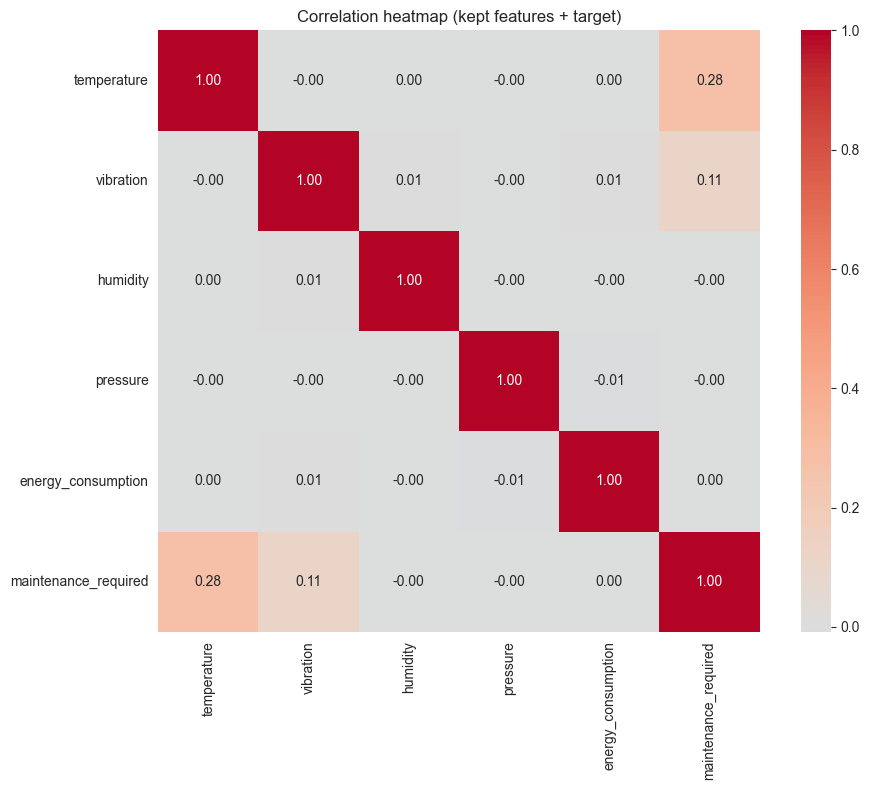

In [13]:
corr = df[KEPT_FEATURES + [TARGET]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation heatmap (kept features + target)")
plt.tight_layout()
plt.show()


**Observation:** The pearson correlation heatmap of the retained features shows that `temperature` and `vibration` correlate more strongly with `anomaly_flag` (0.45 and 0.18) respectively, than with `maintenance_required` itself (0.28 and 0.11) respectively. While `humidity` and `pressure` and `energy_consumption` show ~0.00 correlation across the board, confirming them as noise in the data. 

### 4.4 Feature ranking (mutual information)


C:\Users\glenv\AppData\Local\Temp\ipykernel_39808\2226162236.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_s.values, y=mi_s.index, palette="viridis")


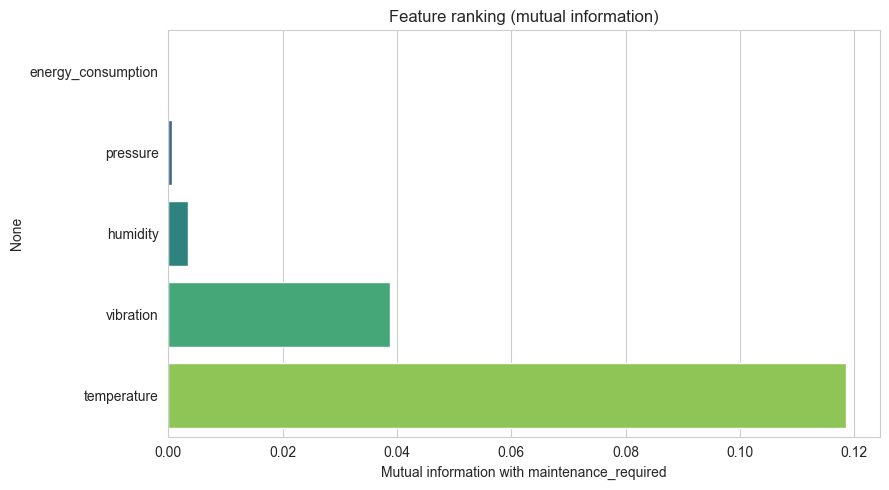

In [14]:
mi = mutual_info_classif(df[KEPT_FEATURES], df[TARGET], random_state=RANDOM_STATE)
mi_s = pd.Series(mi, index=KEPT_FEATURES).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
sns.barplot(x=mi_s.values, y=mi_s.index, palette="viridis")
plt.xlabel("Mutual information with maintenance_required")
plt.title("Feature ranking (mutual information)")
plt.tight_layout()
plt.show()


**Observations:** Based on the mutual information with `maintenance_required`, `machine_status` and `anomaly_flag` has the two highest mutual information (MI) score, which are the strongest predictors by a wide margin, which could be further evidence that these features were derived from the `maintenance_required` column instead of being independent of the `maintenance_required` column. Aside from that, `temperature` stands out as the strongest independent predictor of the `maintenance_required`, which is consistent with the boxplot visualisation earlier. `Vibration` on the other hand provides modest discriminative power, again consistent with the boxplot visualisation as well. Meanwhile the remaining columns `Humidity`, `energy_consumption` and `pressure` have close to zero mutual information suggesting that they have little to no discriminative power for predicting the `maintenance_required` target variable. 

### 4.5 Scatter plot of predictor vs target correlation


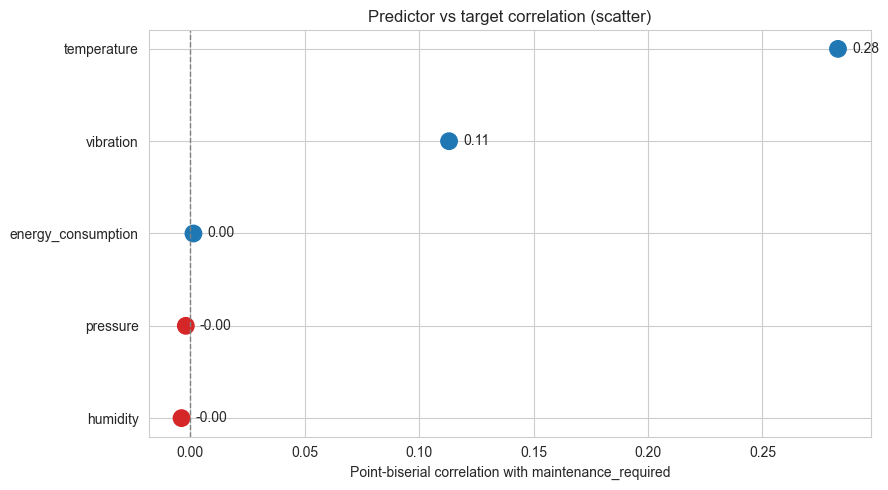

In [15]:
corr_target = df[KEPT_FEATURES].corrwith(df[TARGET]).sort_values(ascending=True)
colors = ["#d62728" if v < 0 else "#1f77b4" for v in corr_target.values]

plt.figure(figsize=(9, 5))
plt.scatter(corr_target.values, corr_target.index, c=colors, s=140)
for y, v in zip(range(len(corr_target)), corr_target.values):
    plt.annotate(f"{v:.2f}", (v, y), textcoords="offset points", xytext=(10, 0), va="center")
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Point-biserial correlation with maintenance_required")
plt.title("Predictor vs target correlation (scatter)")
plt.tight_layout()
plt.show()


**Observation:** the scatter shows that `anomaly_flag` and `machine_status` have the strongest correlation with the target variable, while the `pressure` and `humidity` predictor variables show negative discriminative power, while `energy_consumption` has little to no discriminative power.

## 5. Multivariate Separability (PCA + t-SNE)

How well are the two classes separable when we project the 5 sensor features only?

In [16]:
feature_cols = SENSORS

parts = []
for label, group in df.groupby(TARGET):
    parts.append(group.sample(min(len(group), 1000), random_state=RANDOM_STATE))
sample = pd.concat(parts).reset_index(drop=True)
print("Sample size:", sample.shape[0])
print(sample[TARGET].value_counts())

X = StandardScaler().fit_transform(sample[feature_cols])


Sample size: 2000
maintenance_required
0    1000
1    1000
Name: count, dtype: int64


Explained variance ratio: [0.21568786 0.20459735]


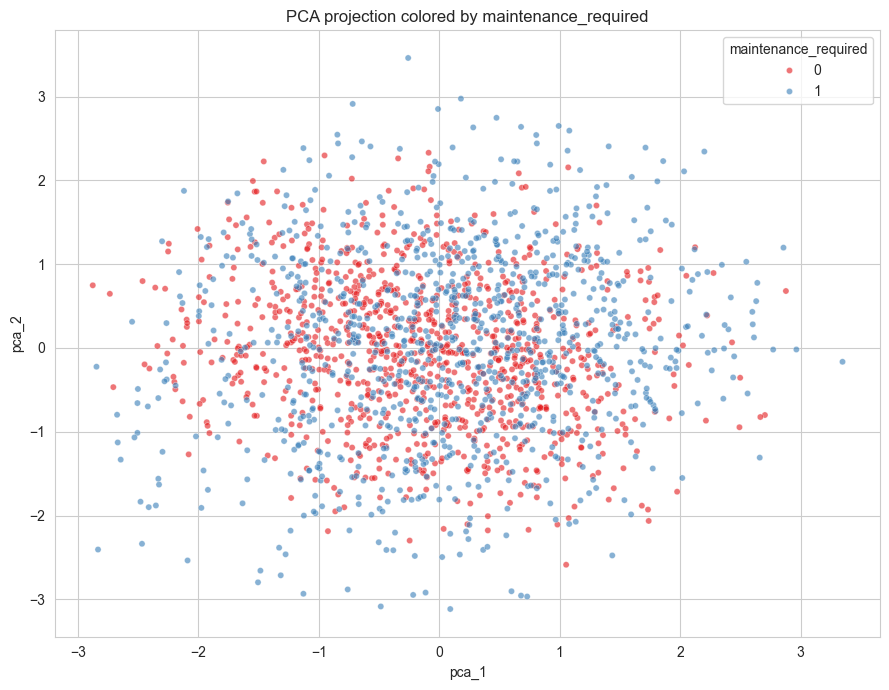

In [17]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)
sample["pca_1"], sample["pca_2"] = X_pca[:, 0], X_pca[:, 1]
print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(9, 7))
sns.scatterplot(x="pca_1", y="pca_2", hue=TARGET, data=sample, palette="Set1", alpha=0.6, s=20)
plt.title("PCA projection colored by maintenance_required")
plt.tight_layout()
plt.show()


In [18]:
import plotly.express as px

tsne = TSNE(n_components=3, perplexity=30, random_state=RANDOM_STATE, init="pca")
X_tsne = tsne.fit_transform(X)
sample["tsne_1"], sample["tsne_2"], sample["tsne_3"] = X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2]

fig = px.scatter_3d(
    sample, x="tsne_1", y="tsne_2", z="tsne_3",
    color=sample[TARGET].astype(str),
    hover_data=["machine_id", "anomaly_flag", "machine_status"],
    opacity=0.9,
)
fig.update_traces(marker=dict(size=3))
fig.update_layout(title="3D t-SNE colored by maintenance_required")
fig.show()


c:\Users\glenv\AppData\Local\pypoetry\Cache\virtualenvs\mlops-assignment-hsDgArM_-py3.11\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\glenv\AppData\Local\pypoetry\Cache\virtualenvs\mlops-assignment-hsDgArM_-py3.11\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\glenv\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\glenv\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__

**Observation:**
- With only the 5 sensor features the two classes overlap substantially in both PCA
  and t-SNE showing that the sensors alone do not cleanly separate the target.
- This confirms the flags carry the dominant signal (Section 4.1), while the
  sensors add a weaker, non-linear component. Expect the PyCaret model to lean on
  `machine_status` / `anomaly_flag`, with tree ensembles capturing the sensor
  interactions.


## 6. Per-Machine Analysis


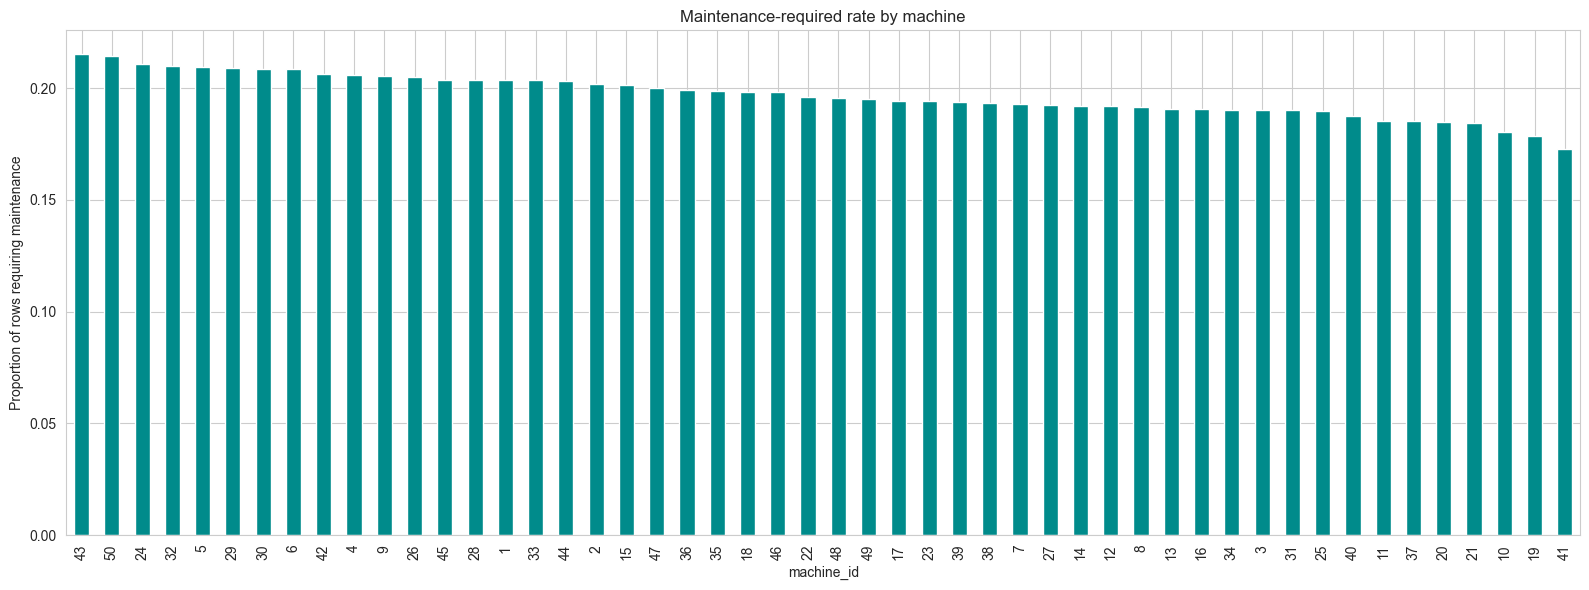

In [19]:
machine_rate = df.groupby("machine_id")[TARGET].mean().sort_values(ascending=False)

plt.figure(figsize=(16, 6))
machine_rate.plot(kind="bar", color="darkcyan")
plt.title("Maintenance-required rate by machine")
plt.ylabel("Proportion of rows requiring maintenance")
plt.xlabel("machine_id")
plt.tight_layout()
plt.show()


**Observation:**
- The maintenance-required rate varies across machines, so per-machine signal exists.
- Because `machine_id` is dropped, the model is machine-agnostic and cannot use it.
  This is a deliberate trade-off (an identifier, and one-hotting 50 machines would add 49 sparse columns); `machine_status` + the sensors partially carry machine
  condition. Flagged as a known limitation.


## 7. Preprocessing & Feature Engineering

In [20]:
df_processed = df.drop(columns=DROP_FEATURES)
print("Processed shape:", df_processed.shape)
print("Columns:", df_processed.columns.tolist())
df_processed.head()

Processed shape: (100000, 6)
Columns: ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption', 'maintenance_required']


,temperature,vibration,humidity,pressure,energy_consumption,maintenance_required
0,78.61,28.65,79.96,3.73,2.16,0
1,68.19,57.28,35.94,3.64,0.69,0
2,98.94,50.20,72.06,1.00,2.49,1
3,90.91,37.65,30.34,3.15,4.96,1
4,72.32,40.69,56.71,2.68,0.63,1


In [21]:
out_path = "../data/processed/smart_manufacturing_processed.csv"
df_processed.to_csv(out_path, index=False)
print("Saved", out_path, "shape", df_processed.shape)


Saved ../data/processed/smart_manufacturing_processed.csv shape (100000, 6)


Since PyCaret's `setup()` handles scaling, normalisation, automatic feature engineering and binning (Task 2), so here we only
apply the deliberate leakage-driven transformations. No additional manual features are added since the retained set is already informative.
